In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.pyplot as plt


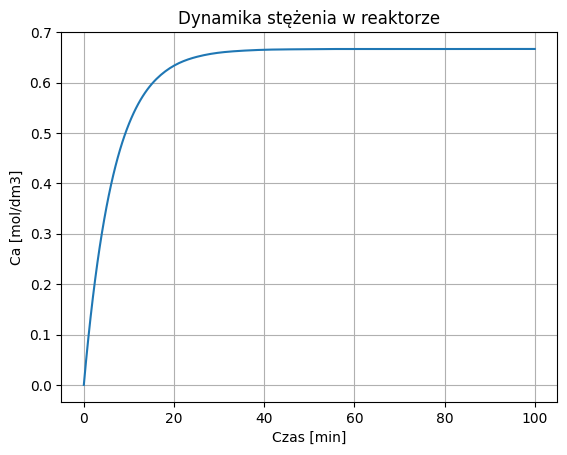

In [2]:
# Model z Zadania 1
def model(t, y, q, V, k, Caf):
    return [(q/V)*(Caf - y[0]) - k*y[0]]

# Parametry przekazywane jako 'args' do solvera
q, V, k, Caf = 5.0, 100.0, 0.1, 2.0
params = (q, V, k, Caf)

# Rozwiązanie zagadnienia Cauchy'ego
sol = solve_ivp(model, [0, 100], [0.0], args=params, t_eval=np.linspace(0, 100, 200))

# Wykres
plt.plot(sol.t, sol.y[0])
plt.title("Dynamika stężenia w reaktorze")
plt.xlabel("Czas [min]"); plt.ylabel("Ca [mol/dm3]")
plt.grid(True); plt.show()

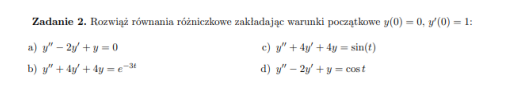

In [8]:


img = Image.open("C:\\Users\\Stasiu\\VS_CODE\\L_WPD_1\\Równania.png")

plt.imshow(img)
plt.axis("off")  # hide axes
plt.show()

In [9]:
# Definicja warunków początkowych: y(0)=0, y'(0)=1
y0 = [0, 1]
t_span = (0, 10)  # przedział czasu od 0 do 10
t_eval = np.linspace(0, 10, 500)  # punkty, w których chcemy znać wynik

In [10]:
# Definicje równań (pochodne)
def ode_a(t, v):
    y, dy = v
    d2y = 2*dy - y
    return [dy, d2y]

def ode_b(t, v):
    y, dy = v
    d2y = np.exp(-3*t) - 4*dy - 4*y
    return [dy, d2y]

def ode_c(t, v):
    y, dy = v
    d2y = np.sin(t) - 4*dy - 4*y
    return [dy, d2y]

def ode_d(t, v):
    y, dy = v
    d2y = np.cos(t) + 2*dy - y
    return [dy, d2y]

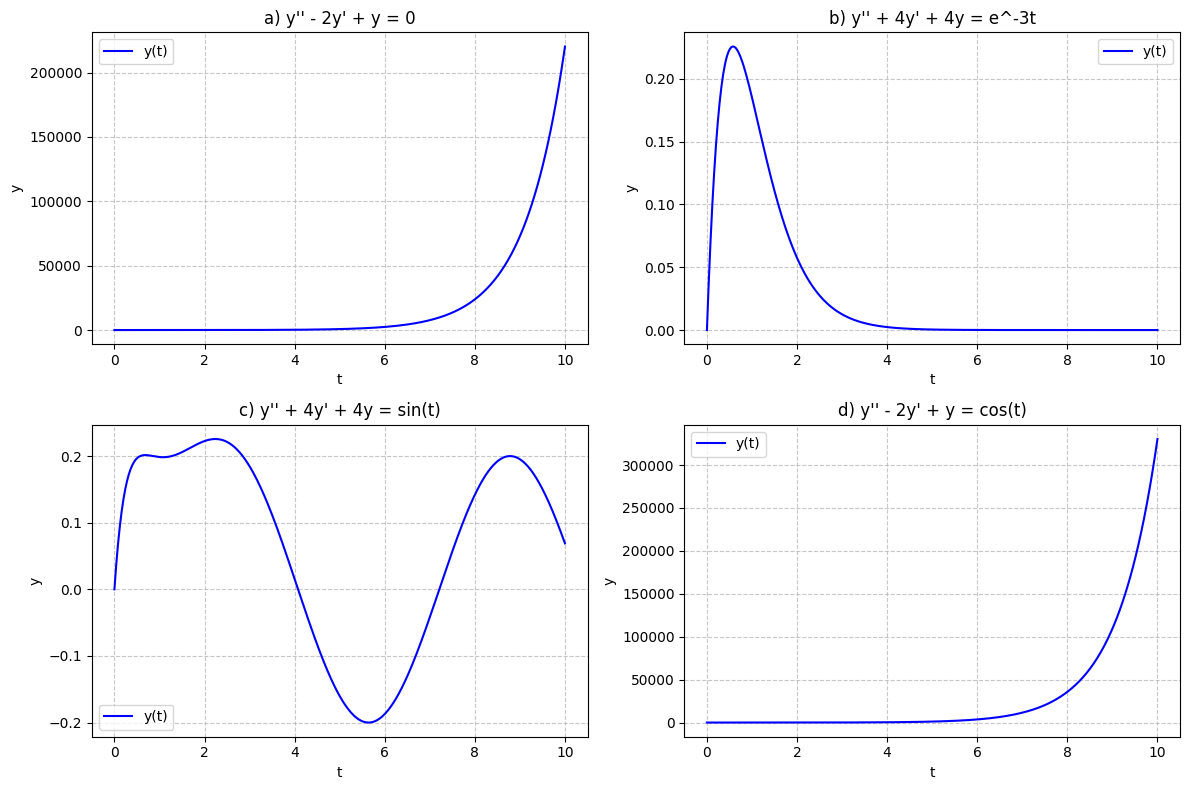

In [11]:
# Rozwiązywanie
equations = [ode_a, ode_b, ode_c, ode_d]
titles = ['a) y\'\' - 2y\' + y = 0', 'b) y\'\' + 4y\' + 4y = e^-3t', 
          'c) y\'\' + 4y\' + 4y = sin(t)', 'd) y\'\' - 2y\' + y = cos(t)']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, ode in enumerate(equations):
    sol = solve_ivp(ode, t_span, y0, t_eval=t_eval)
    
    axes[i].plot(sol.t, sol.y[0], label='y(t)', color='blue')
    axes[i].set_title(titles[i])
    axes[i].grid(True, linestyle='--', alpha=0.7)
    axes[i].set_xlabel('t')
    axes[i].set_ylabel('y')
    axes[i].legend()

plt.tight_layout()
plt.show()